In [1]:
from combine_data import combine_data
from datetime import datetime

from labels import VQEParameters
from hamiltonian.base import HamiltonianParameters
from misc import data_folder
from solver.circuits import rebuild_ansatz, BaseADAPTVQEAnsatz
import h5py
from plotter import ResultLoader
from matplotlib import pyplot as plt
import numpy as np
from numpyencoder import NumpyEncoder
import json
from misc import plots_folder
from pathlib import Path

In [2]:
output_filename = plots_folder
# temp = "2025-09-35"
# output_filename += temp
output_filename += datetime.now().strftime('%Y-%m-%U')  #datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
Path(output_filename).mkdir(parents=True, exist_ok=True)
output_filename += "/"
output_filename

'results/plots/2025-10-42/'

In [3]:
combine_data()

-----Combining data-----
Skipping combined file 2025-08-34.hdf5
Skipping combined file 2025-09-35.hdf5
Skipping combined file 2025-10-42.hdf5
Skipping combined file 2025-08-33.hdf5
-----Finished combining data-----


In [10]:
h5_file = f"{data_folder}{"2025-09-35"}.hdf5"
h5_file

'results/data/2025-09-35.hdf5'

In [7]:
global_info_dict = {}
with h5py.File(h5_file, "r") as f:
    for key, value in f.items():
        loader = ResultLoader(value)
        name, info_dict = loader.info_dict({})
        global_info_dict[name] = info_dict
with open(f"{output_filename}info.json", "w") as finfo:
    json.dump(global_info_dict, finfo, sort_keys=True, indent=4, cls=NumpyEncoder)

In [8]:
with h5py.File(h5_file, "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    ed_energy, ed_mass = ed_loader.get_energy_mass({})
    vqe_1_loader = ResultLoader(f["2025-09-02_17-46-07"])
    vqe_1_energy, vqe_1_mass = vqe_1_loader.get_energy_mass({})
    vqe_2_loader = ResultLoader(f["2025-09-03_11-10-56"])
    vqe_2_energy, vqe_2_mass = vqe_2_loader.get_energy_mass({})
    vqe_3_loader = ResultLoader(f["2025-09-03_11-11-36"])
    vqe_3_energy, vqe_3_mass = vqe_3_loader.get_energy_mass({})
    vqe_4_loader = ResultLoader(f["2025-09-03_11-12-33"])
    vqe_4_energy, vqe_4_mass = vqe_4_loader.get_energy_mass({})

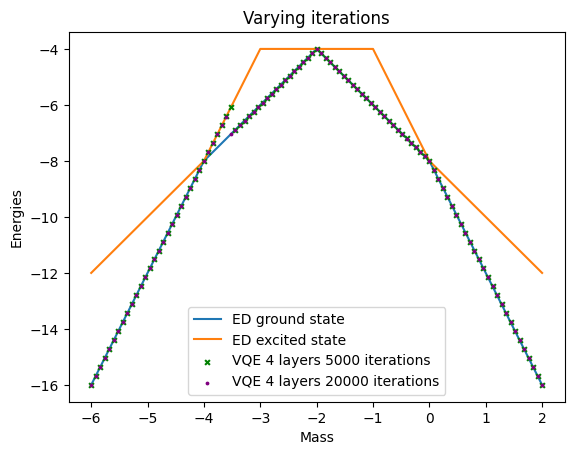

In [9]:
fig, ax = plt.subplots()
ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1)
ax.plot(ed_mass, ed_energy[:, 1], label="ED excited state", zorder=-1)
ax.scatter(vqe_1_mass, vqe_1_energy, label="VQE 4 layers 5000 iterations", marker='x', s=12, color='green')
ax.scatter(vqe_2_mass, vqe_2_energy, label="VQE 4 layers 20000 iterations", marker='.', s=12, color='purple')
ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Varying iterations")
ax.legend()
fig.savefig(f"{output_filename}varying_iterations.png")
fig.savefig(f"{output_filename}varying_iterations.pdf")

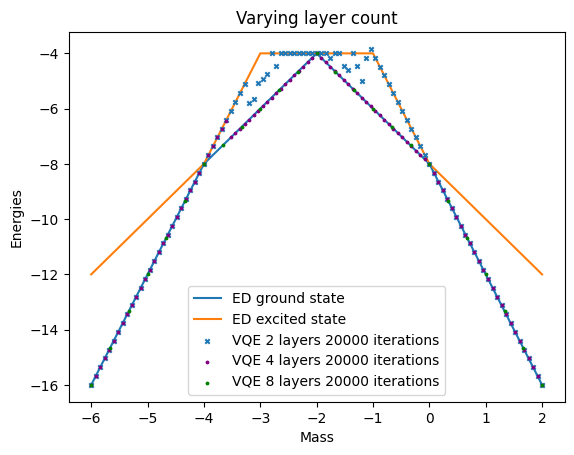

In [10]:
fig, ax = plt.subplots()
ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1)
ax.plot(ed_mass, ed_energy[:, 1], label="ED excited state", zorder=-1)
ax.scatter(vqe_3_mass, vqe_3_energy, label="VQE 2 layers 20000 iterations", marker='x', s=10)
ax.scatter(vqe_2_mass, vqe_2_energy, label="VQE 4 layers 20000 iterations", marker='.', color='purple', s=12)
ax.scatter(vqe_4_mass, vqe_4_energy, label="VQE 8 layers 20000 iterations", marker='.', color='green', s=12)
ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Varying layer count")
ax.legend()
fig.savefig(f"{output_filename}varying_layer_count.png")
fig.savefig(f"{output_filename}varying_layer_count.pdf")

ParameterView([ParameterVectorElement(phi[0]), ParameterVectorElement(phi[1]), ParameterVectorElement(phi[2]), ParameterVectorElement(phi[3]), ParameterVectorElement(phi[4]), ParameterVectorElement(phi[5]), ParameterVectorElement(phi[6]), ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11]), ParameterVectorElement(θ[12]), ParameterVectorElement(θ[13]), ParameterVectorElement(θ[14]), ParameterVectorElement(θ[15]), ParameterVectorElement(θ[16]), ParameterVectorElement(θ[17]), ParameterVectorElement(θ[18]), ParameterVectorElement(θ[19]), ParameterVectorElement(θ[20]), ParameterVectorElement(θ[21]), ParameterVectorElement(θ[22])])


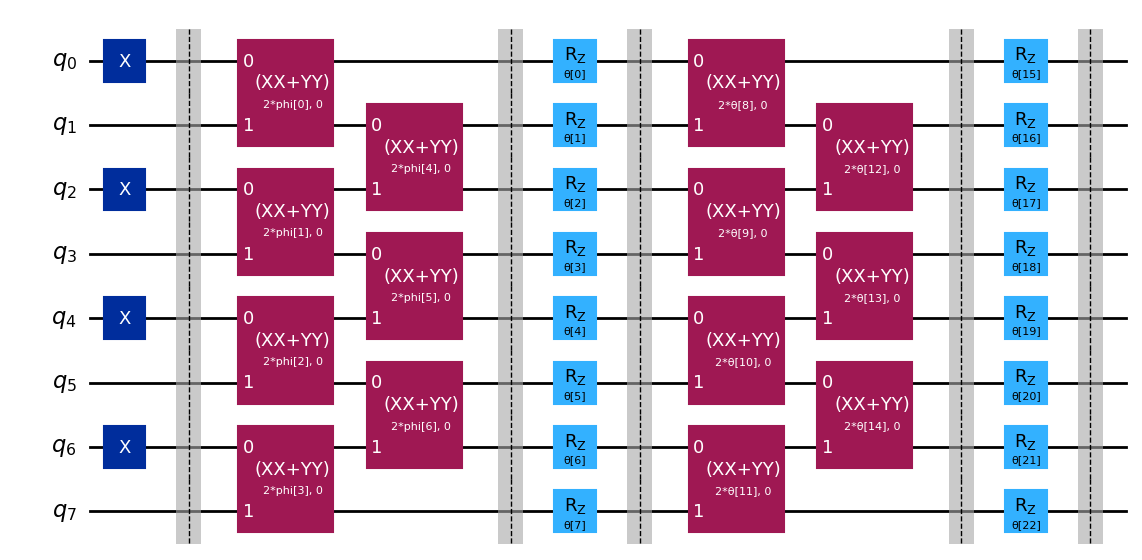

In [11]:
with h5py.File(h5_file, "r") as f:
    circuit = rebuild_ansatz(f["2025-09-03_11-10-56"])
    circuit = rebuild_ansatz(f["2025-09-03_11-11-36"])
    # circuit = rebuild_ansatz(f["2025-09-03_11-12-33"])
print(circuit.full_ansatz.parameters)
circuit.full_ansatz.draw("mpl", filename=f"{output_filename}circuit-2-layer.pdf")

ParameterView([ParameterVectorElement(phi[0]), ParameterVectorElement(phi[1]), ParameterVectorElement(phi[2]), ParameterVectorElement(phi[3]), ParameterVectorElement(phi[4]), ParameterVectorElement(phi[5]), ParameterVectorElement(phi[6]), ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11]), ParameterVectorElement(θ[12]), ParameterVectorElement(θ[13]), ParameterVectorElement(θ[14]), ParameterVectorElement(θ[15]), ParameterVectorElement(θ[16]), ParameterVectorElement(θ[17]), ParameterVectorElement(θ[18]), ParameterVectorElement(θ[19]), ParameterVectorElement(θ[20]), ParameterVectorElement(θ[21]), ParameterVectorElement(θ[22])])


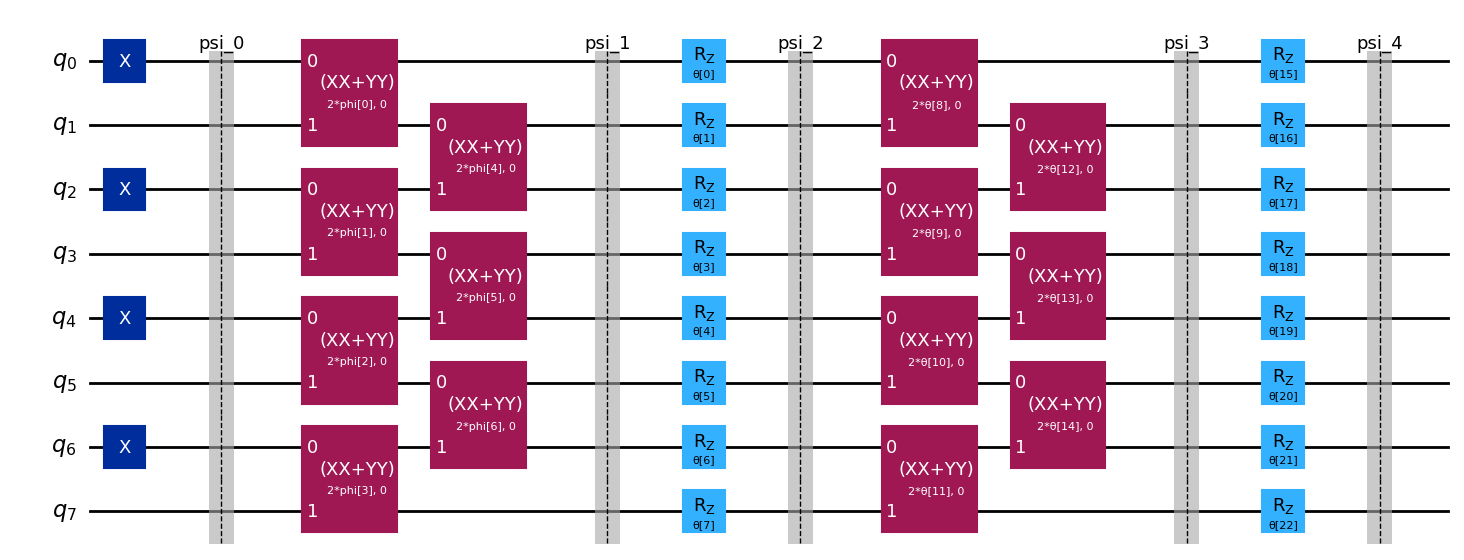

In [13]:
temp = circuit.build_full_ansatz_with_save_points()[0]
print(temp.parameters)
temp.draw("mpl")

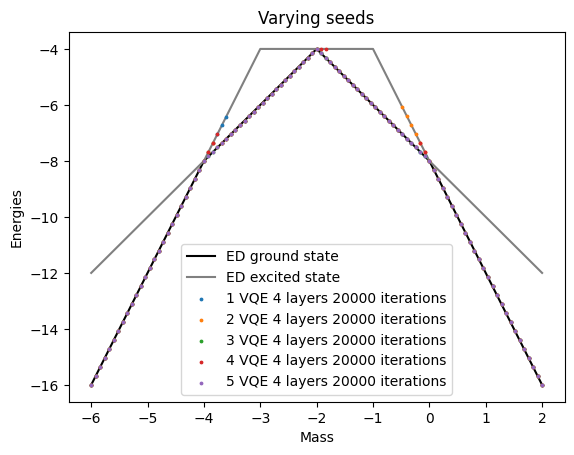

In [14]:
with h5py.File(h5_file, "r") as f:
    vqe_1_loader = ResultLoader(f["2025-09-03_11-10-56"])
    vqe_1_energy, vqe_1_mass = vqe_1_loader.get_energy_mass({})
    vqe_2_loader = ResultLoader(f["2025-09-06_15-50-13"])
    vqe_2_energy, vqe_2_mass = vqe_2_loader.get_energy_mass({})
    vqe_3_loader = ResultLoader(f["2025-09-06_15-50-13-23147802"])
    vqe_3_energy, vqe_3_mass = vqe_3_loader.get_energy_mass({})
    vqe_4_loader = ResultLoader(f["2025-09-06_15-50-13-23147804"])
    vqe_4_energy, vqe_4_mass = vqe_4_loader.get_energy_mass({})
    vqe_5_loader = ResultLoader(f["2025-09-06_15-50-13-23147805"])
    vqe_5_energy, vqe_5_mass = vqe_5_loader.get_energy_mass({})
fig, ax = plt.subplots()
ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1, color="black")
ax.plot(ed_mass, ed_energy[:, 1], label="ED excited state", zorder=-1, color="gray")
ax.scatter(vqe_1_mass, vqe_1_energy, label="1 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.scatter(vqe_2_mass, vqe_2_energy, label="2 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.scatter(vqe_3_mass, vqe_3_energy, label="3 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.scatter(vqe_4_mass, vqe_4_energy, label="4 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.scatter(vqe_5_mass, vqe_5_energy, label="5 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Varying seeds")
ax.legend()
fig.savefig(f"{output_filename}varying_seeds.png")
fig.savefig(f"{output_filename}varying_seeds.pdf")

In [15]:
def count_differences(labels: list[str]):
    base_label = "10101010"
    diffs = []
    for label in labels:
        if label:
            temp = 0
            for posit, letter in enumerate(label):
                if letter == base_label[posit]:
                    pass
                else:
                    temp += 1
            diffs.append(temp)
    return diffs


plt.rcParams['figure.constrained_layout.use'] = True
with h5py.File(h5_file, "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    for pos in range(0, 1000, 100):
        print(f"Mass = {ed_mass[pos]:.2f}:")
        gs_fig, gs_labels = ed_loader.plot_ground_state({HamiltonianParameters.Mass: pos})
        gs_diffs = count_differences(gs_labels)
        print("GS", np.sum(gs_diffs), gs_diffs)
        gs_fig.savefig(f"{output_filename}gs_m_{ed_mass[pos]:.2f}.png")
        plt.close(gs_fig)

        es_fig, es_labels = ed_loader.plot_excited_state({HamiltonianParameters.Mass: pos})
        es_diffs = count_differences(es_labels)
        print("ES", np.sum(es_diffs), es_diffs)
        es_fig.savefig(f"{output_filename}es_m_{ed_mass[pos]:.2f}.png")
        plt.close(es_fig)

Mass = -6.00:
(-4.5, 0.0)
(4.5, 0.0)
(25.5, 0.0)
(34.5, 0.0)
(-4.5, 30.0)
(4.5, 30.0)
(25.5, 30.0)
(34.5, 30.0)
GS 4 [4]
(-4.5, 0.0)
(4.5, 0.0)
(25.5, 0.0)
(34.5, 0.0)
(-4.5, 30.0)
(4.5, 30.0)
(25.5, 30.0)
(34.5, 30.0)
ES 64 [4, 4, 6, 6, 4, 4, 6, 2, 2, 2, 2, 4, 4, 6, 4, 4]
Mass = -5.20:
(-4.5, 0.0)
(4.5, 0.0)
(25.5, 0.0)
(34.5, 0.0)
(-4.5, 30.0)
(4.5, 30.0)
(25.5, 30.0)
(34.5, 30.0)
GS 4 [4]
(-4.5, 0.0)
(4.5, 0.0)
(25.5, 0.0)
(34.5, 0.0)
(-4.5, 30.0)
(4.5, 30.0)
(25.5, 30.0)
(34.5, 30.0)
ES 64 [4, 4, 6, 6, 4, 4, 6, 2, 2, 2, 2, 4, 4, 6, 4, 4]
Mass = -4.40:
(-4.5, 0.0)
(4.5, 0.0)
(25.5, 0.0)
(34.5, 0.0)
(-4.5, 30.0)
(4.5, 30.0)
(25.5, 30.0)
(34.5, 30.0)
GS 4 [4]
(-4.5, 0.0)
(4.5, 0.0)
(25.5, 0.0)
(34.5, 0.0)
(-4.5, 30.0)
(4.5, 30.0)
(25.5, 30.0)
(34.5, 30.0)
ES 64 [4, 4, 6, 6, 4, 4, 6, 2, 2, 2, 2, 4, 4, 6, 4, 4]
Mass = -3.60:
(-4.5, 0.0)
(4.5, 0.0)
(25.5, 0.0)
(34.5, 0.0)
(-4.5, 30.0)
(4.5, 30.0)
(25.5, 30.0)
(34.5, 30.0)
GS 64 [4, 4, 6, 6, 4, 4, 6, 2, 2, 2, 2, 4, 4, 6, 4, 4]
(-4.5, 0.0)

In [11]:
with h5py.File(h5_file, "r") as f:
    for pos in range(10, 100, 10):
        ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
        sel = {HamiltonianParameters.Mass: pos * 10}
        print(ed_loader.get_parameter_values_from_indices(sel))
        ref_state = ed_loader.get_ground_state(sel)

        vqe_5_loader = ResultLoader(f["2025-09-06_15-50-13-23147805"])
        sel = {HamiltonianParameters.Mass: pos}
        sel_values = vqe_5_loader.get_parameter_values_from_indices(sel)
        print(sel_values)

        overlaps = vqe_5_loader.save_overlap_evolution(sel, ref_state, output_filename, 1)

{<HamiltonianParameters.Mass: 'mass'>: np.float64(-5.2)}
{<HamiltonianParameters.Mass: 'mass'>: np.float64(-5.2)}
_mass_-5.20


KeyboardInterrupt: 

In [4]:
h5_file = f"{data_folder}{"2025-10-42"}.hdf5"
h5_file

'results/data/2025-10-42.hdf5'

{<HamiltonianParameters.Mass: 'mass'>: np.float64(-6.0)}
[[-2.00000000e+00  2.50000000e+00 -2.50000000e+00  2.00000000e+00
   2.00000000e+00 -2.50000000e+00  2.50000000e+00 -2.00000000e+00
   5.00000000e-01  0.00000000e+00 -5.00000000e-01  4.00000000e+00
  -5.00000000e-01 -6.93889390e-18  5.00000000e-01]
 [-2.00000000e+00  2.50000000e+00 -2.35355274e+00  2.12131904e+00
   2.12131904e+00 -2.35355274e+00  2.50000000e+00 -2.00000000e+00
   5.00000000e-01  1.46447259e-01  2.07108080e-01 -1.46928204e-05
   2.07108080e-01  1.46447259e-01  5.00000000e-01]
 [-2.00000000e+00  7.85133552e-06 -2.00000111e+00  2.12132281e+00
   2.12132281e+00 -2.35355462e+00  2.50000000e+00 -2.00000000e+00
   1.57026710e-06 -3.53553052e-01  7.07102747e-01  2.78763067e-05
   2.07104317e-01  1.46445377e-01  5.00000000e-01]
 [-2.00000000e+00  1.07323014e-05 -2.00000152e+00  2.12132470e+00
   2.12132470e+00 -2.00005580e+00  3.94531886e-04 -2.00000000e+00
   2.14646029e-06 -3.53553424e-01  7.07100276e-01  4.93180948e-0

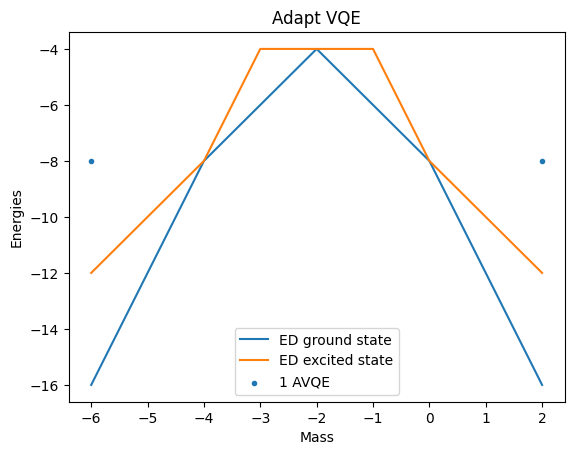

In [20]:
with h5py.File(h5_file, "r") as f:
    avqe_1_loader = ResultLoader(f["2025-10-21_16-15-16-23708113"])
    avqe_1_energy, avqe_1_mass = avqe_1_loader.get_energy_mass({})
    for i in [0, 1]:
        params = {HamiltonianParameters.Mass: i}
        print(avqe_1_loader.get_parameter_values_from_indices(params))
        print(avqe_1_loader.get_observables(VQEParameters.AnsatzOperatorDerivatives,params, [])[0])
        print(avqe_1_loader.get_observables(VQEParameters.AnsatzOperators,params, [])[0])
    params = {HamiltonianParameters.Mass: 0}
    circuit = avqe_1_loader.get_circuit(params, True)
fig, ax = plt.subplots()
with h5py.File(f"{data_folder}{"2025-09-35"}.hdf5", "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    ed_energy, ed_mass = ed_loader.get_energy_mass({})

ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1)
ax.plot(ed_mass, ed_energy[:, 1], label="ED excited state", zorder=-1)
ax.scatter(avqe_1_mass, avqe_1_energy, label="1 AVQE", marker='.')
ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Adapt VQE")
ax.legend()
plt.show()

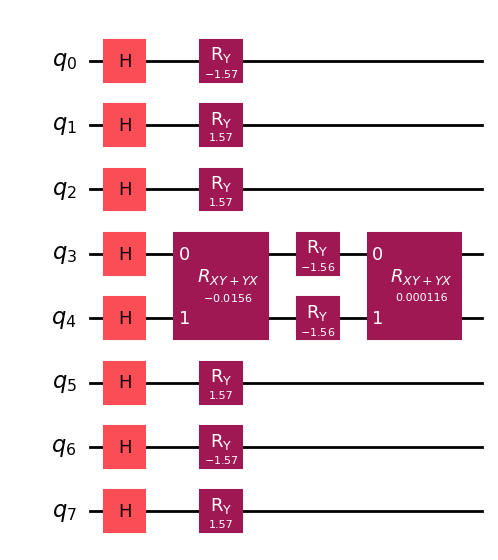

In [21]:
circuit.draw("mpl")